## Late-delivery classification objective

The main stakeholders are e-commerce platform operators and sellers, who could use predicted late-delivery risk to prioritise high-risk orders for closer fulfilment monitoring and proactive customer communication. The model is intended as decision support rather than automated intervention.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
consolidated = pd.read_csv(
    '/content/drive/MyDrive/IT5006_Olist_Project/smartcommerce_consolidated_v2.csv'
)
print(consolidated.shape)
print(consolidated.columns.tolist())

(112650, 45)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_english', 'product_weight_g', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_state', 'customer_city', 'seller_state', 'order_date', 'year_month', 'year', 'month', 'day_of_week', 'delivery_days', 'is_on_time', 'item_revenue', 'customer_unique_id', 'customer_zip_code_prefix', 'seller_zip_code_prefix', 'seller_city', 'payment_total', 'payment_max_installments', 'n_payment_methods', 'main_payment_type', 'review_score', 'review_creation_date', 'review_answer_timestamp', 'has_review_comment', 'is_low_review', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'distance_km', 'same_state', 'promised_days']


In [ ]:
consolidated.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,product_weight_g,customer_id,...,review_answer_timestamp,has_review_comment,is_low_review,customer_lat,customer_lng,seller_lat,seller_lng,distance_km,same_state,promised_days
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.0,3ce436f183e68e07877b285a838db11a,...,2017-09-22 10:57:03,True,False,-21.762775,-41.309633,-22.496953,-44.127492,301.5,False,15
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.0,f6dd3ec061db4e3987629fe6b26e5cce,...,2017-05-15 11:34:13,False,False,-20.220527,-50.903424,-23.565096,-46.518565,585.6,True,18
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,3050.0,6489ae5e4333f3693df5ad4372dab6d3,...,2018-01-23 16:06:31,True,False,-19.870305,-44.593326,-22.262584,-46.171124,312.3,True,21
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,200.0,d4eb9395c8c0431ee92fce09860c5a06,...,2018-08-15 16:39:01,False,False,-23.089925,-46.611654,-20.553624,-47.387359,293.2,True,11
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,3750.0,58dbd0b2d70206bf40e62cd34e84d795,...,2017-03-03 10:54:59,True,False,-23.243402,-46.827614,-22.929384,-53.135873,646.2,False,40


In [ ]:
print("Rows:", len(consolidated))
print("Unique orders:", consolidated['order_id'].nunique())

Rows: 112650
Unique orders: 98666


In [ ]:
consolidated['is_on_time'].value_counts(dropna=False)

,count
is_on_time,
True,101481
False,11169


In [ ]:
consolidated[['order_status',
              'order_delivered_customer_date',
              'order_estimated_delivery_date',
              'is_on_time']].head(10)

,order_status,order_delivered_customer_date,order_estimated_delivery_date,is_on_time
0,delivered,2017-09-20 23:43:48,2017-09-29,True
1,delivered,2017-05-12 16:04:24,2017-05-15,True
2,delivered,2018-01-22 13:19:16,2018-02-05,True
3,delivered,2018-08-14 13:32:39,2018-08-20,True
4,delivered,2017-03-01 16:42:31,2017-03-17,True
5,delivered,2017-05-22 13:44:35,2017-06-06,True
6,delivered,2017-12-18 22:03:38,2018-01-04,True
7,delivered,2018-07-09 14:04:07,2018-07-25,True
8,delivered,2018-03-29 18:17:31,2018-03-29,False
9,delivered,2018-07-04 17:28:31,2018-07-23,True


In [ ]:
print("Rows:", len(consolidated))
print("Unique orders:", consolidated['order_id'].nunique())

Rows: 112650
Unique orders: 98666


In [ ]:
order_level = consolidated.drop_duplicates('order_id')

print(order_level['is_on_time'].value_counts(dropna=False))
print(order_level['is_on_time'].value_counts(normalize=True, dropna=False) * 100)

is_on_time
True     88649
False    10017
Name: count, dtype: int64
is_on_time
True     89.847567
False    10.152433
Name: proportion, dtype: float64


In [ ]:
order_level['order_status'].value_counts(dropna=False)

,count
order_status,
delivered,96478
shipped,1106
canceled,461
invoiced,312
processing,301
unavailable,6
approved,2


In [ ]:
delivered_orders = order_level[
    order_level['order_status'] == 'delivered'
].copy()

print("Delivered orders:", len(delivered_orders))

print(
    delivered_orders['is_on_time']
    .value_counts(dropna=False)
)

print(
    delivered_orders['is_on_time']
    .value_counts(normalize=True, dropna=False) * 100
)

Delivered orders: 96478
is_on_time
True     88644
False     7834
Name: count, dtype: int64
is_on_time
True     91.880014
False     8.119986
Name: proportion, dtype: float64


In [ ]:
order_level = consolidated.drop_duplicates('order_id').copy()

delivered_orders = order_level[
    order_level['order_status'] == 'delivered'
].copy()

delivered_orders['is_late'] = (~delivered_orders['is_on_time']).astype(int)

In [ ]:
print("Delivered orders:", len(delivered_orders))
print("Late orders:", delivered_orders['is_late'].sum())
print("Late rate:", delivered_orders['is_late'].mean())

Delivered orders: 96478
Late orders: 7834
Late rate: 0.08119985903522046


In [ ]:
# Create an order-level view for delivery outcome analysis
order_level = consolidated.drop_duplicates('order_id').copy()

# Keep only successfully delivered orders
delivered_orders = order_level[
    order_level['order_status'] == 'delivered'
].copy()

# Define late delivery target using the v2 field
delivered_orders['is_late'] = (
    ~delivered_orders['is_on_time']
).astype(int)

In [ ]:
print(order_level.shape)

(98666, 45)


In [ ]:
print("Order-level rows:", len(order_level))
print("Delivered orders:", len(delivered_orders))
print("Late orders:", delivered_orders['is_late'].sum())
print(
    "Late rate:",
    f"{delivered_orders['is_late'].mean() * 100:.2f}%"
)

Order-level rows: 98666
Delivered orders: 96478
Late orders: 7834
Late rate: 8.12%


### Analysis sample and class imbalance

The late-delivery analysis is restricted to successfully delivered orders. Among 96,478 delivered orders, 7,834 (8.12%) were delivered late, indicating substantial class imbalance. Therefore, accuracy alone may be misleading; precision, recall, F1-score and AUROC should be considered for later classification modelling. Resampling or class weighting may be evaluated in Phase 2 rather than applied automatically.

Because only successfully delivered orders are included, the findings describe lateness among completed deliveries and may not generalise to cancelled, unavailable or otherwise unfulfilled orders.

## What features are related to late delivery?
Test in order:
1.  Temporal
*   monthly v.s weekly
2. Geography
*   same state delivery v.s cross-state delivery
*   late rate by customer state
*   late rate by seller state
*   spacial distance
3.   Order cost or physical characteristics
*   Freight
*   Freight ratio
*   Price
*   Weight
4. Product category
5. Item count


## 1. Temporal
*   monthly v.s weekly



In [ ]:
late_by_month = (
    delivered_orders.groupby('year_month')
    .agg(
        late_rate=('is_late', 'mean'),
        order_count=('order_id', 'count')
    )
    .reset_index()
)

late_by_month['late_rate_pct'] = late_by_month['late_rate'] * 100

late_by_month

,year_month,late_rate,order_count,late_rate_pct
0,2016-09,1.000000,1,100.000000
1,2016-10,0.011321,265,1.132075
2,2016-12,0.000000,1,0.000000
3,2017-01,0.030667,750,3.066667
4,2017-02,0.032063,1653,3.206292
5,2017-03,0.055774,2546,5.577376
6,2017-04,0.078593,2303,7.859314
7,2017-05,0.036379,3546,3.637902
8,2017-06,0.038596,3135,3.859649
9,2017-07,0.034349,3872,3.434917


In [ ]:
late_by_weekday = (
    delivered_orders.groupby('day_of_week')
    .agg(
        late_rate=('is_late', 'mean'),
        order_count=('order_id', 'count')
    )
)

late_by_weekday['late_rate_pct'] = late_by_weekday['late_rate'] * 100

late_by_weekday.sort_values('late_rate_pct', ascending=False)

,late_rate,order_count,late_rate_pct
day_of_week,,,
Monday,0.090504,15701,9.050379
Tuesday,0.084951,15503,8.495130
Friday,0.084545,13685,8.454512
Wednesday,0.078137,15076,7.813744
Saturday,0.075983,10555,7.598295
Thursday,0.075752,14323,7.575229
Sunday,0.075118,11635,7.511818


Monthly eda results worth scrutinization.

In [ ]:
late_by_month_plot = late_by_month[
    late_by_month['order_count'] >= 500
]

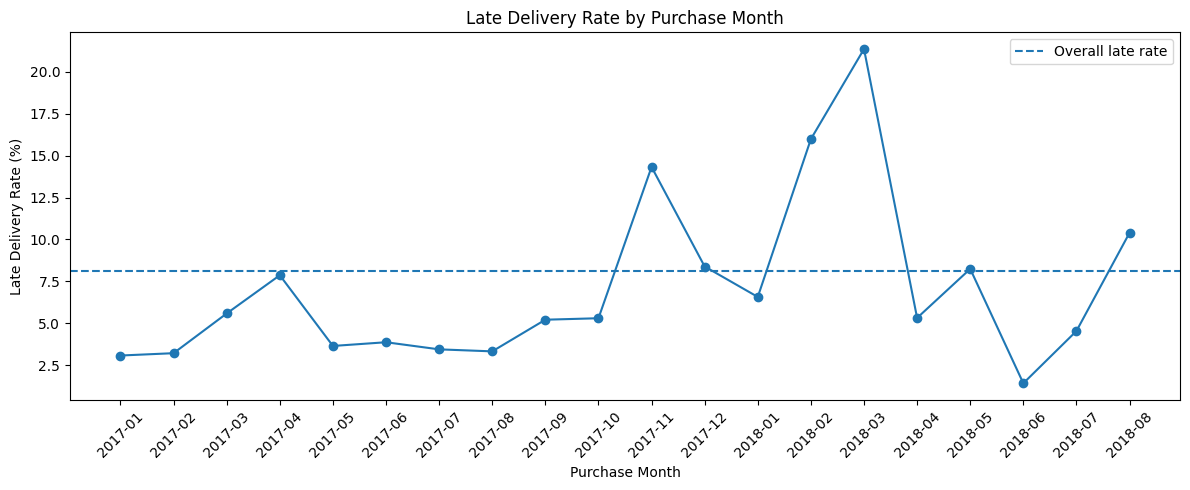

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    late_by_month_plot['year_month'],
    late_by_month_plot['late_rate_pct'],
    marker='o'
)

plt.axhline(
    delivered_orders['is_late'].mean() * 100,
    linestyle='--',
    label='Overall late rate'
)

plt.xticks(rotation=45)
plt.xlabel('Purchase Month')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Late Delivery Rate by Purchase Month')
plt.legend()
plt.tight_layout()
plt.show()

Late-delivery rates show substantial temporal variation. While the overall late-delivery rate is approximately 8.1%, rates increased sharply in several periods, reaching 14.3% in November 2017, 16.0% in February 2018 and 21.4% in March 2018. These fluctuations suggest that order timing may be associated with delivery risk and could be considered as a candidate predictive feature in Phase 2.

## 2. Geography
*   same state delivery v.s cross-state delivery
*   late rate by customer state
*   late rate by seller state
*   seller-customer spatial distance











In [ ]:
geo_delivered = consolidated[
    consolidated['order_status'] == 'delivered'
].copy()

In [ ]:
geo_delivered['same_state'].value_counts(dropna=False)

,count
same_state,
False,70331
True,39866


In [ ]:
same_state_per_order = (
    geo_delivered.groupby('order_id')['same_state']
    .nunique()
)

same_state_per_order.value_counts()

,count
same_state,
1,96231
2,247


In [ ]:
order_geo = (
    geo_delivered.groupby('order_id')
    .agg(
        same_state_order=('same_state', 'all')
    )
    .reset_index()
)

In [ ]:
delivered_orders = delivered_orders.merge(
    order_geo,
    on='order_id',
    how='left'
)

In [ ]:
same_state_summary = (
    delivered_orders.groupby('same_state_order')
    .agg(
        late_rate=('is_late', 'mean'),
        order_count=('order_id', 'count')
    )
    .reset_index()
)

same_state_summary['late_rate_pct'] = (
    same_state_summary['late_rate'] * 100
)

same_state_summary

,same_state_order,late_rate,order_count,late_rate_pct
0,False,0.092507,61898,9.250703
1,True,0.060960,34580,6.096009


To handle orders involving multiple sellers, an order was classified as cross-state **if at least one seller was located in a different state from the customer**. Using this order-level definition, cross-state orders showed a higher late-delivery rate (9.25%) than same-state orders (6.10%), suggesting that greater geographic separation may be associated with higher delivery risk.

In [ ]:
late_by_state = (
    delivered_orders
    .groupby('customer_state')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

late_by_state['late_rate'] *= 100

late_by_state = (
    late_by_state[late_by_state['orders'] >= 100]
    .sort_values('late_rate', ascending=False)
    .reset_index(drop=True)
)

late_by_state

,customer_state,late_rate,orders
0,AL,23.929471,397
1,MA,19.665272,717
2,PI,15.966387,476
3,CE,15.324472,1279
4,SE,15.223881,335
5,BA,14.035627,3256
6,RJ,13.473684,12350
7,TO,12.773723,274
8,PA,12.367865,946
9,ES,12.230576,1995


Late-delivery rates differ substantially across customer states, from 2.88% in RO to 23.93% in AL. Because state-level sample sizes vary considerably, these differences should be interpreted together with **95% confidence intervals** rather than from point estimates alone.

In [ ]:
p = late_by_state['late_rate'] / 100
n = late_by_state['orders']

se = np.sqrt(p * (1 - p) / n)

late_by_state['ci_lower'] = (p - 1.96 * se) * 100
late_by_state['ci_upper'] = (p + 1.96 * se) * 100

In [ ]:
late_by_state[
    ['customer_state', 'late_rate', 'orders', 'ci_lower', 'ci_upper']
]

,customer_state,late_rate,orders,ci_lower,ci_upper
0,AL,23.929471,397,19.732504,28.126438
1,MA,19.665272,717,16.755907,22.574636
2,PI,15.966387,476,12.675731,19.257042
3,CE,15.324472,1279,13.350266,17.298678
4,SE,15.223881,335,11.376784,19.070977
5,BA,14.035627,3256,12.842493,15.228760
6,RJ,13.473684,12350,12.871485,14.075883
7,TO,12.773723,274,8.821302,16.726144
8,PA,12.367865,946,10.269942,14.465788
9,ES,12.230576,1995,10.792839,13.668314


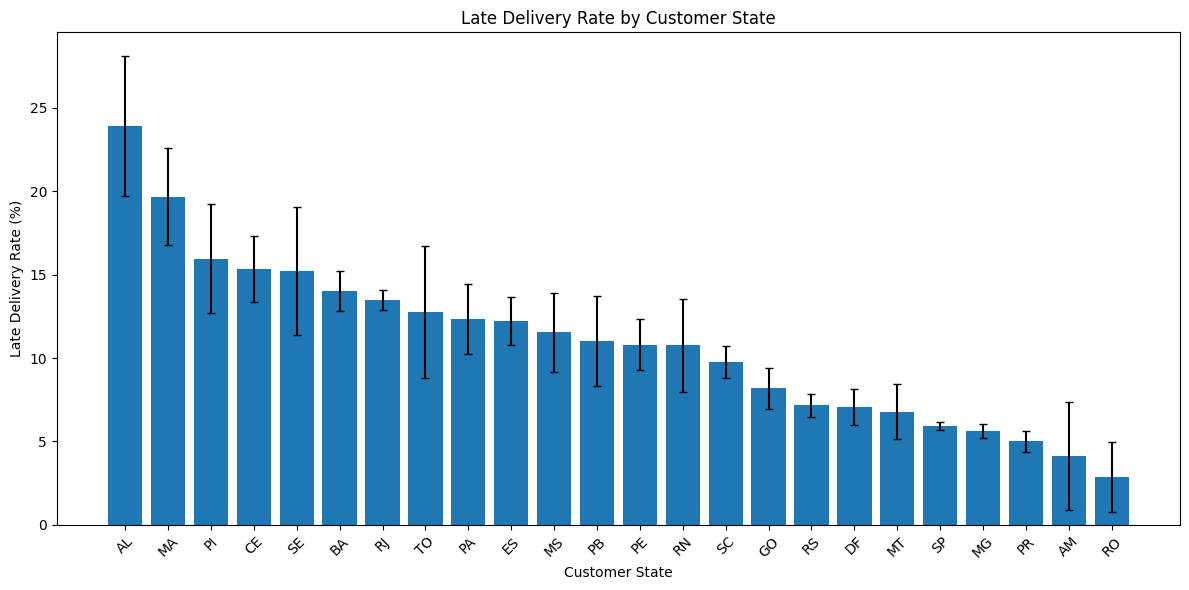

In [ ]:
plt.figure(figsize=(12, 6))

yerr = [
    late_by_state['late_rate'] - late_by_state['ci_lower'],
    late_by_state['ci_upper'] - late_by_state['late_rate']
]

plt.bar(
    late_by_state['customer_state'],
    late_by_state['late_rate'],
    yerr=yerr,
    capsize=3
)

plt.title('Late Delivery Rate by Customer State')
plt.xlabel('Customer State')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The 95% confidence intervals indicate greater uncertainty for states with smaller sample sizes, while estimates for high-volume states such as SP and RJ are more precise. RJ is particularly notable because it combines a relatively high late-delivery rate (13.47%) with a large number of orders.

In [ ]:
seller_state_orders = (
    geo_delivered[
        ['order_id', 'seller_state', 'is_on_time']
    ]
    .drop_duplicates(['order_id', 'seller_state'])
    .copy()
)

seller_state_orders['is_late'] = (
    ~seller_state_orders['is_on_time']
).astype(int)

In [ ]:
late_by_seller_state = (
    seller_state_orders
    .groupby('seller_state')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

late_by_seller_state['late_rate'] *= 100

late_by_seller_state = (
    late_by_seller_state[
        late_by_seller_state['orders'] >= 100
    ]
    .sort_values('late_rate', ascending=False)
    .reset_index(drop=True)
)

late_by_seller_state

,seller_state,late_rate,orders
0,MA,23.136247,389
1,SP,8.752786,68641
2,RJ,8.398391,4227
3,ES,7.096774,310
4,PR,6.456337,7512
5,DF,6.064356,808
6,SC,5.967250,3603
7,BA,5.818182,550
8,MG,5.610860,7735
9,PE,4.466501,403


In [ ]:
p = late_by_seller_state['late_rate'] / 100
n = late_by_seller_state['orders']

se = np.sqrt(p * (1 - p) / n)

late_by_seller_state['ci_lower'] = (p - 1.96 * se) * 100
late_by_seller_state['ci_upper'] = (p + 1.96 * se) * 100

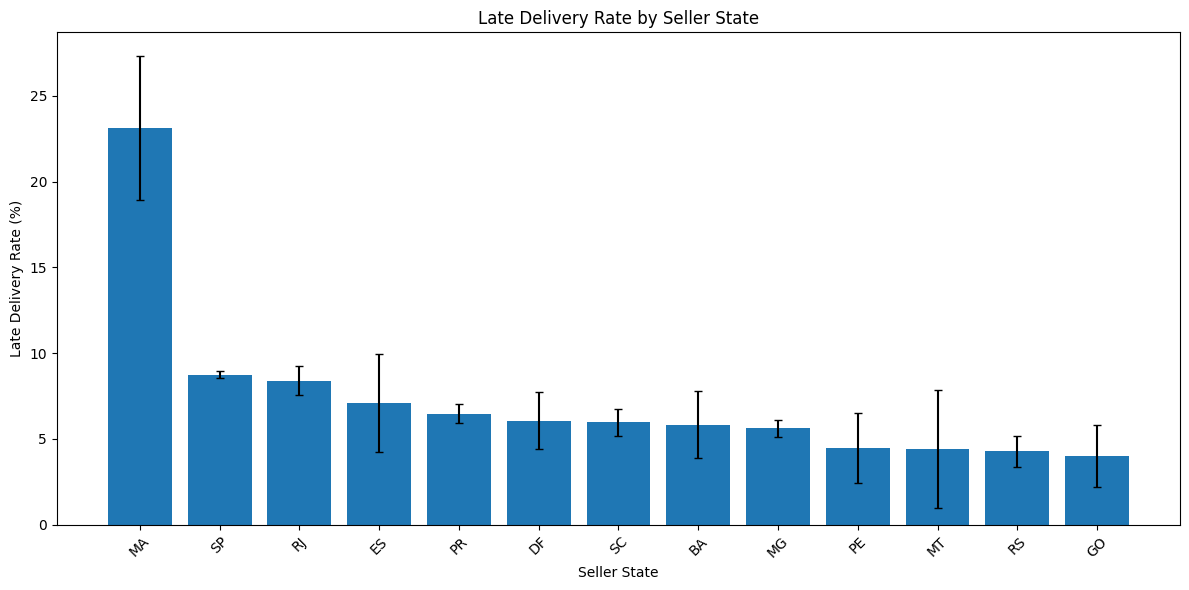

In [ ]:
plt.figure(figsize=(12, 6))

yerr = [
    late_by_seller_state['late_rate'] - late_by_seller_state['ci_lower'],
    late_by_seller_state['ci_upper'] - late_by_seller_state['late_rate']
]

plt.bar(
    late_by_seller_state['seller_state'],
    late_by_seller_state['late_rate'],
    yerr=yerr,
    capsize=3
)

plt.title('Late Delivery Rate by Seller State')
plt.xlabel('Seller State')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Seller-state late-delivery rates also vary across regions. MA shows the highest observed rate, although its confidence interval is relatively wide, while large seller states such as SP and RJ show more stable estimates. Because multi-seller orders may contribute to more than one seller-state group, these results are interpreted as exploratory rather than mutually exclusive state-level comparisons.

seller-customer spatial distance

In [ ]:
order_distance = (
    geo_delivered.groupby('order_id')
    .agg(
        max_distance_km=('distance_km', 'max')
    )
    .reset_index()
)

In [ ]:
delivered_orders = delivered_orders.merge(
    order_distance,
    on='order_id',
    how='left'
)

In [ ]:
delivered_orders['max_distance_km'].describe()

,max_distance_km
count,96002.000000
mean,602.097015
std,593.914932
min,0.000000
25%,189.300000
50%,435.600000
75%,800.300000
max,8677.900000


In [ ]:
delivered_orders['distance_group'] = pd.qcut(
    delivered_orders['max_distance_km'],
    q=5,
    duplicates='drop'
)

In [ ]:
late_by_distance = (
    delivered_orders
    .groupby('distance_group', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

late_by_distance['late_rate_pct'] = (
    late_by_distance['late_rate'] * 100
)

late_by_distance

,distance_group,late_rate,orders,late_rate_pct
0,"(-0.001, 117.6]",0.065556,19205,6.555584
1,"(117.6, 348.6]",0.068657,19197,6.865656
2,"(348.6, 531.4]",0.075397,19205,7.539703
3,"(531.4, 877.5]",0.085434,19196,8.543447
4,"(877.5, 8677.9]",0.110370,19199,11.037033


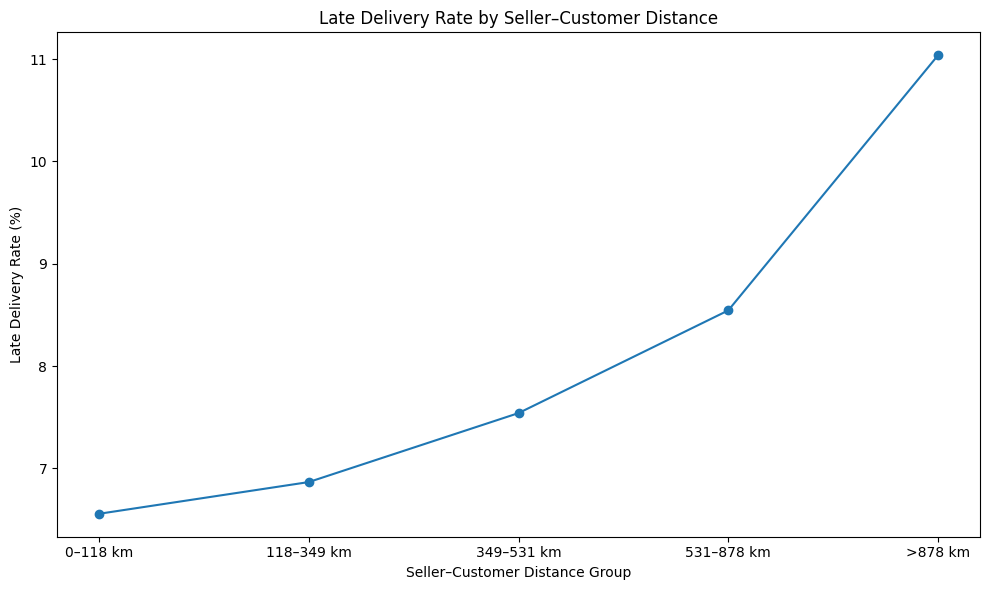

In [ ]:
distance_labels = [
    '0–118 km',
    '118–349 km',
    '349–531 km',
    '531–878 km',
    '>878 km'
]

plt.figure(figsize=(10, 6))

plt.plot(
    distance_labels,
    late_by_distance['late_rate_pct'],
    marker='o'
)

plt.title('Late Delivery Rate by Seller–Customer Distance')
plt.xlabel('Seller–Customer Distance Group')
plt.ylabel('Late Delivery Rate (%)')

plt.tight_layout()
plt.show()

Late-delivery risk increased progressively with seller–customer distance. Orders in the shortest-distance quintile had a late-delivery rate of 6.56%, compared with 11.04% in the longest-distance quintile. This monotonic pattern suggests that spatial distance is a potentially useful predictor of delivery risk.
Distance is represented by the maximum seller–customer distance within each order, so multi-seller orders are characterised by their furthest fulfilment leg.

Distance information was available for 96,002 of the 96,478 delivered orders. The remaining 476 orders (0.49%) had missing seller–customer distance information and were excluded from the distance-based analysis.

In [ ]:
total_delivered = len(delivered_orders)
distance_available = delivered_orders['max_distance_km'].notna().sum()
distance_missing = delivered_orders['max_distance_km'].isna().sum()
distance_missing_pct = distance_missing / total_delivered * 100

print("Delivered orders:", total_delivered)
print("Distance available:", distance_available)
print("Distance missing:", distance_missing)
print(f"Missing rate: {distance_missing_pct:.2f}%")

Delivered orders: 96478
Distance available: 96002
Distance missing: 476
Missing rate: 0.49%




## 3.   Order cost or physical characteristics
* Freight
* Freight ratio
* Price
* Weight





In [ ]:
order_features = (
    consolidated.groupby('order_id')
    .agg(
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        avg_product_weight=('product_weight_g', 'mean'),
        item_count=('order_item_id', 'count')
    )
    .reset_index()
)
delivered_orders['freight_ratio'] = (
    delivered_orders['total_freight'] /
    delivered_orders['total_price']
)


In [ ]:
delivered_orders = delivered_orders.merge(
    order_features,
    on='order_id',
    how='left'
)

In [ ]:
delivered_orders.groupby('is_late')[
    ['total_freight', 'total_price', 'avg_product_weight', 'freight_ratio']
].agg(['mean', 'median'])

total_freight        total_price        avg_product_weight         \
                 mean median        mean median               mean median   
is_late                                                                     
0           22.623544  17.07  136.064803   85.5        2071.854114  688.0   
1           24.615036  18.05  148.094165   89.9        2397.020252  750.0   

        freight_ratio            
                 mean    median  
is_late                          
0            0.307755  0.224374  
1            0.315324  0.226757

In [ ]:
delivered_orders['freight_bin'] = pd.qcut(
    delivered_orders['total_freight'],
    q=5,
    duplicates='drop'
)

freight_late = (
    delivered_orders
    .groupby('freight_bin', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

freight_late['late_rate'] *= 100

freight_late

,freight_bin,late_rate,orders
0,"(-0.001, 12.83]",6.087943,19399
1,"(12.83, 15.64]",7.247056,19194
2,"(15.64, 18.59]",8.864352,19381
3,"(18.59, 27.38]",9.059705,19228
4,"(27.38, 1794.96]",9.348413,19276


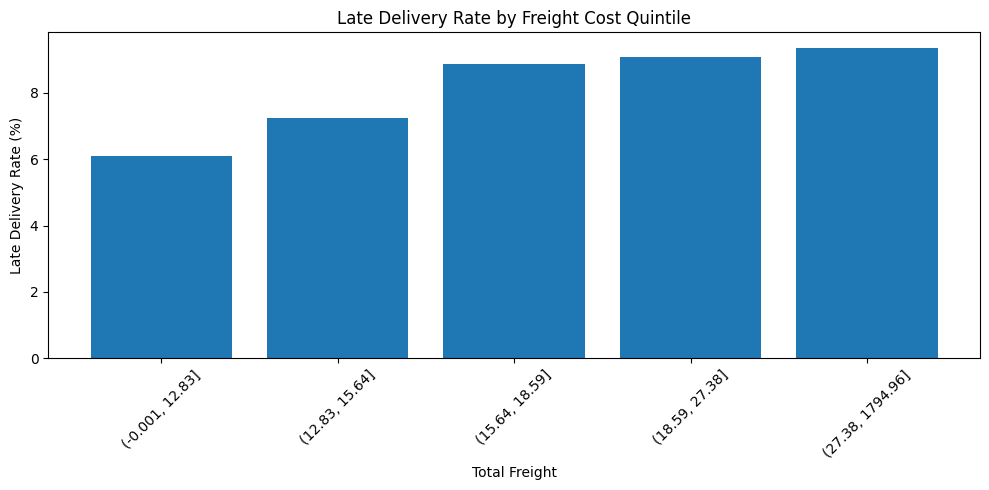

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    freight_late['freight_bin'].astype(str),
    freight_late['late_rate']
)

plt.title('Late Delivery Rate by Freight Cost Quintile')
plt.xlabel('Total Freight')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Late-delivery rates generally increased across higher freight-cost quintiles, rising from 6.08% in the lowest freight group to 9.35% in the highest. This suggests that higher freight costs may be associated with greater delivery risk, although freight cost may also reflect underlying factors such as shipping distance, product characteristics or order composition.

In [ ]:
print((delivered_orders['total_price'] == 0).sum())

delivered_orders['freight_ratio'].describe()

0


,freight_ratio
count,96478.000000
mean,0.308370
std,0.311610
min,0.000000
25%,0.132016
50%,0.224374
75%,0.380531
max,21.447059


In [ ]:
delivered_orders['freight_ratio_bin'] = pd.qcut(
    delivered_orders['freight_ratio'],
    q=5,
    duplicates='drop'
)

freight_ratio_late = (
    delivered_orders
    .groupby('freight_ratio_bin', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

freight_ratio_late['late_rate'] *= 100

freight_ratio_late

,freight_ratio_bin,late_rate,orders
0,"(-0.001, 0.115]",8.286692,19296
1,"(0.115, 0.183]",7.939881,19295
2,"(0.183, 0.274]",7.609033,19306
3,"(0.274, 0.435]",8.395522,19296
4,"(0.435, 21.447]",8.369199,19285


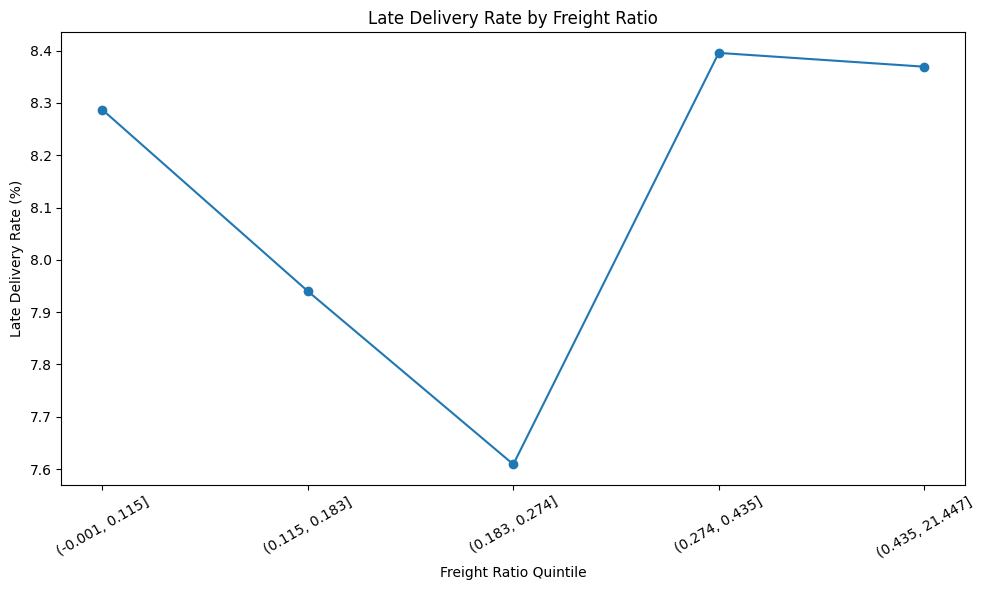

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    freight_ratio_late['freight_ratio_bin'].astype(str),
    freight_ratio_late['late_rate'],
    marker='o'
)

plt.title('Late Delivery Rate by Freight Ratio')
plt.xlabel('Freight Ratio Quintile')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Unlike absolute freight cost, freight ratio does not show a clear monotonic relationship with late-delivery risk. Late rates remain broadly stable across freight-ratio quintiles, ranging from approximately 7.6% to 8.4%. This suggests that the absolute shipping cost may be more informative than freight cost relative to order value.
The observed association between absolute freight cost and lateness may partly reflect other factors such as shipping distance, product weight, or order composition.

In [ ]:
delivered_orders['price_bin'] = pd.qcut(
    delivered_orders['total_price'],
    q=5,
    duplicates='drop'
)

price_late = (
    delivered_orders.groupby('price_bin', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

price_late['late_rate'] *= 100

price_late

,price_bin,late_rate,orders
0,"(0.849, 39.0]",7.289739,19452
1,"(39.0, 67.9]",7.961833,19179
2,"(67.9, 106.752]",7.935189,19256
3,"(106.752, 175.0]",8.637753,19299
4,"(175.0, 13440.0]",8.780842,19292


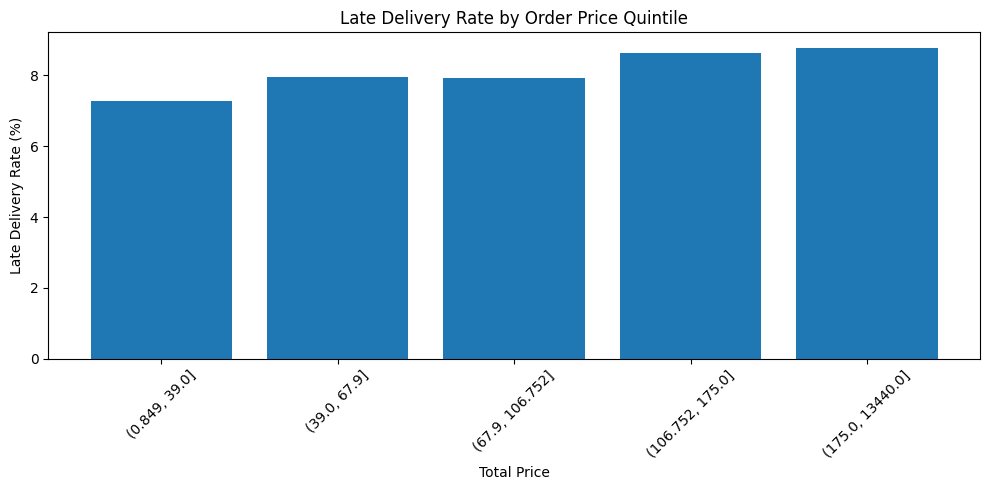

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    price_late['price_bin'].astype(str),
    price_late['late_rate']
)

plt.title('Late Delivery Rate by Order Price Quintile')
plt.xlabel('Total Price')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Late-delivery rates were slightly higher for more expensive orders, increasing from about 7.3% in the lowest price quintile to 8.8% in the highest quintile. The relationship appears weaker than the pattern observed for freight cost.

In [ ]:
delivered_orders['weight_bin'] = pd.qcut(
    delivered_orders['avg_product_weight'],
    q=5,
    duplicates='drop'
)

weight_late = (
    delivered_orders.groupby('weight_bin', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

weight_late['late_rate'] *= 100

weight_late

,weight_bin,late_rate,orders
0,"(-0.001, 250.0]",7.346683,22323
1,"(250.0, 500.0]",8.256135,18459
2,"(500.0, 1000.0]",7.728542,17196
3,"(1000.0, 2500.0]",8.359783,19534
4,"(2500.0, 40425.0]",9.013193,18950


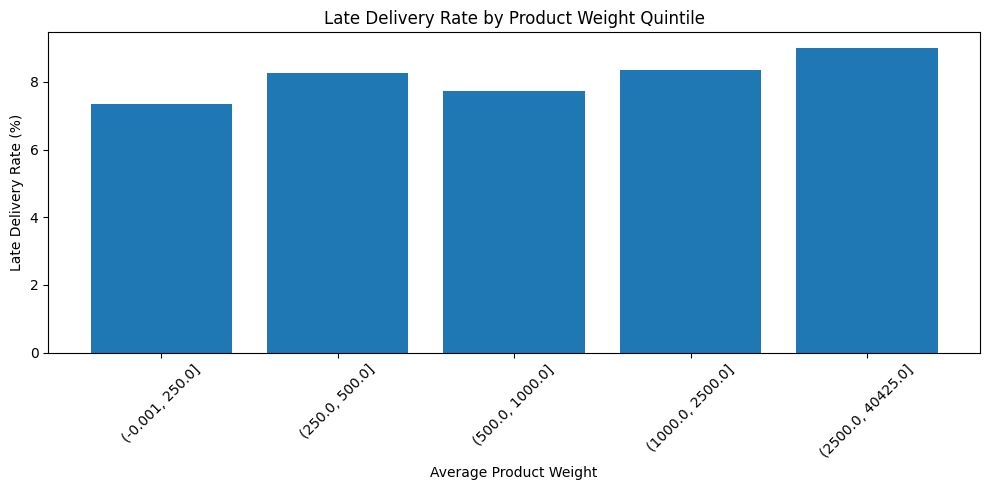

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    weight_late['weight_bin'].astype(str),
    weight_late['late_rate']
)

plt.title('Late Delivery Rate by Product Weight Quintile')
plt.xlabel('Average Product Weight')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Heavier products tended to have somewhat higher late-delivery rates, with the highest-weight quintile reaching about 9.0% compared with 7.3% in the lightest group. However, the relationship was not strictly monotonic.

Freight cost showed the clearest relationship with late delivery, while higher order prices and heavier products were associated with only modest increases in late-delivery rates. Freight ratio showed no clear monotonic pattern. These findings suggest that absolute logistics cost may be more informative than relative freight burden, with price and weight offering weaker supplementary signals.

## 4.   Product category



In [ ]:
category_orders = (
    consolidated[
        consolidated['order_status'] == 'delivered'
    ][
        ['order_id', 'product_category_name_english', 'is_on_time']
    ]
    .drop_duplicates(['order_id', 'product_category_name_english'])
    .copy()
)

category_orders['is_late'] = (
    ~category_orders['is_on_time']
).astype(int)

In [ ]:
category_late = (
    category_orders
    .groupby('product_category_name_english')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

category_late['late_rate'] *= 100

category_late = (
    category_late[
        category_late['orders'] >= 300
    ]
    .sort_values('late_rate', ascending=False)
    .reset_index(drop=True)
)

category_late.head(15)

,product_category_name_english,late_rate,orders
0,audio,12.931034,348
1,home_confort,10.459184,392
2,food,9.977324,441
3,electronics,9.813270,2517
4,baby,9.184763,2809
5,office_furniture,9.170654,1254
6,construction_tools_construction,9.103261,736
7,health_beauty,8.962646,8647
8,musical_instruments,8.837971,611
9,bed_bath_table,8.746764,9272


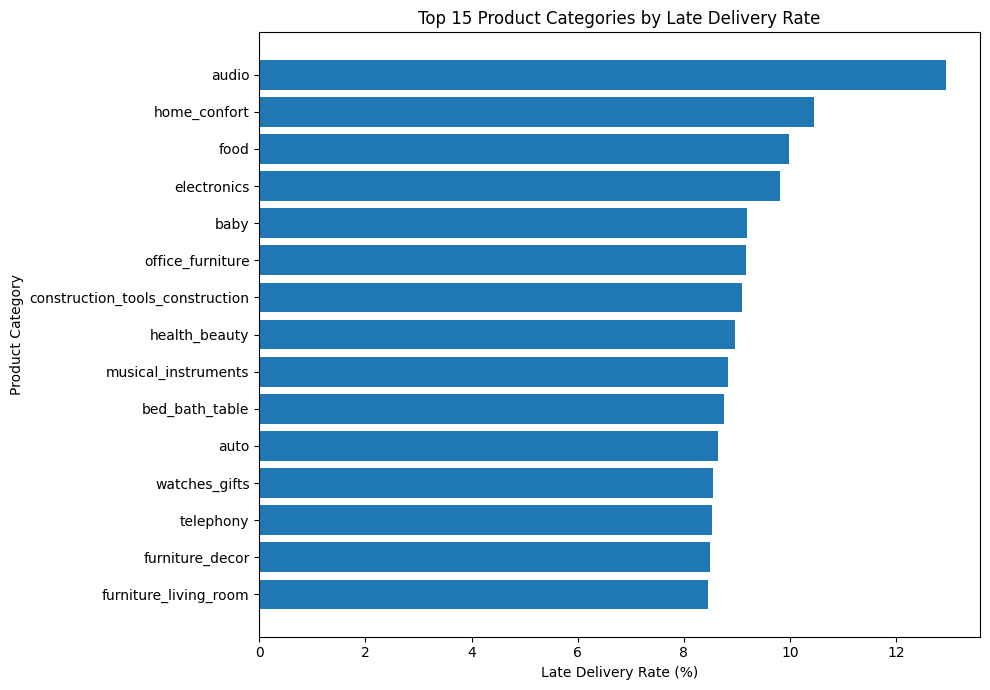

In [ ]:
top_categories = category_late.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_categories['product_category_name_english'],
    top_categories['late_rate']
)

plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Product Category')
plt.title('Top 15 Product Categories by Late Delivery Rate')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Late-delivery rates also varied across product categories. Among categories with at least 300 delivered orders, audio showed the highest observed late rate (12.93%), while several larger categories such as electronics, baby and health & beauty also recorded rates above the overall average. However, category-level differences may partly reflect variation in product characteristics, shipping distance and seller composition, so product category is treated as an exploratory rather than standalone risk factor.

## 5.   Item Count




In [ ]:
delivered_orders['item_count'].value_counts().sort_index().head(15)

,count
item_count,
1,86843
2,7392
3,1306
4,495
5,193
6,191
7,22
8,8
9,3


In [ ]:
delivered_orders['item_count_group'] = pd.cut(
    delivered_orders['item_count'],
    bins=[0, 1, 2, 3, float('inf')],
    labels=['1', '2', '3', '4+']
)

In [ ]:
item_late = (
    delivered_orders.groupby('item_count_group', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

item_late['late_rate'] *= 100

item_late

,item_count_group,late_rate,orders
0,1,8.296581,86843
1,2,6.628788,7392
2,3,6.202144,1306
3,4+,6.189968,937


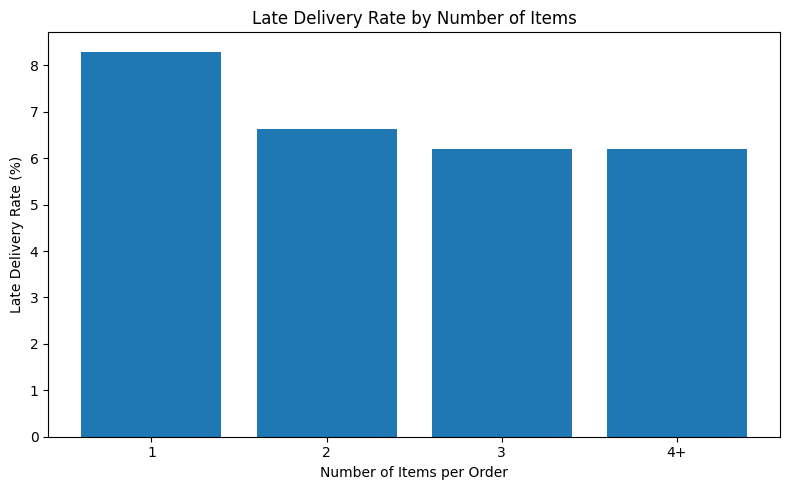

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    item_late['item_count_group'].astype(str),
    item_late['late_rate']
)

plt.title('Late Delivery Rate by Number of Items')
plt.xlabel('Number of Items per Order')
plt.ylabel('Late Delivery Rate (%)')
plt.tight_layout()

plt.show()

Late-delivery rates were highest for single-item orders (8.30%) and lower for orders containing multiple items, falling to around 6.2% for orders with three or more items. This inverse pattern is exploratory and may reflect differences in seller composition, product mix or fulfilment structure rather than a direct effect of item count itself.


## Takeaway

Overall, late-delivery risk was associated with several feature groups. Temporal patterns and geography showed clear variation, with seller–customer distance displaying a particularly consistent increase in late-delivery rates. Among the order characteristics examined, absolute freight cost showed the clearest association with lateness, while higher order prices and heavier products showed weaker positive patterns. In contrast, freight ratio showed little systematic relationship with late delivery, and item count did not show a positive association. Product category also exhibited some variation. Overall, temporal, geographic, logistics-cost, and product-related features appear to be promising candidates for later classification modelling.

### Feature suitability for modelling

Candidate predictors for Phase 2 should be restricted to information available at or shortly after order placement. Post-outcome variables such as actual delivery date, delivery deviation and review-related information should not be used as predictors of late delivery, in order to avoid temporal data leakage.